### Load Packages

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import dask.dataframe as dd

### Import the Data

In [2]:
# path of the three df

df_jan_path = r"..\data\raw\yellow_tripdata_2016-01.csv"
df_feb_path = r"..\data\raw\yellow_tripdata_2016-02.csv"
df_mar_path = r"..\data\raw\yellow_tripdata_2016-03.csv"

# load the data frame

df_jan = dd.read_csv(df_jan_path,assume_missing=True)
df_feb = dd.read_csv(df_feb_path,assume_missing=True)
df_mar = dd.read_csv(df_mar_path,assume_missing=True)

In [3]:
# checking

df_jan

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,pickup_longitude,pickup_latitude,RatecodeID,store_and_fwd_flag,dropoff_longitude,dropoff_latitude,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount
npartitions=26,,,,,,,,,,,,,,,,,,,
,float64,string,string,float64,float64,float64,float64,float64,string,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...


In [4]:
df_jan.shape

(<dask_expr.expr.Scalar: expr=ArrowStringConversion(frame=FromMapProjectable(4113993)).size() // 19, dtype=int64>,
 19)

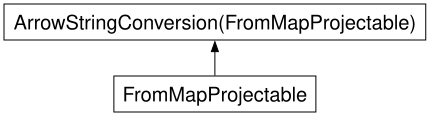

In [5]:
# visualize the chunk

df_jan.visualize()

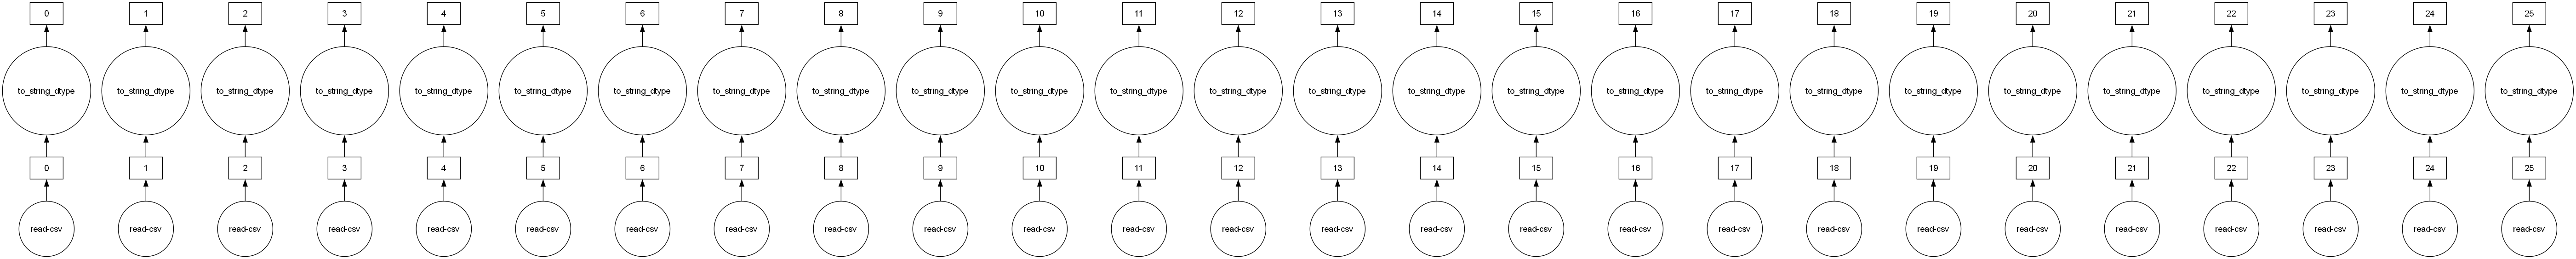

In [6]:
df_jan.visualize(tasks=True)

In [7]:
# shape of all the three dataset

print('Shape of the Jan dataset',df_jan.shape)
print('Shape of the Feb dataset',df_feb.shape)
print('Shape of the Mar dataset',df_mar.shape)

Shape of the Jan dataset (<dask_expr.expr.Scalar: expr=ArrowStringConversion(frame=FromMapProjectable(4113993)).size() // 19, dtype=int64>, 19)
Shape of the Feb dataset (<dask_expr.expr.Scalar: expr=ArrowStringConversion(frame=FromMapProjectable(5ce9648)).size() // 19, dtype=int64>, 19)
Shape of the Mar dataset (<dask_expr.expr.Scalar: expr=ArrowStringConversion(frame=FromMapProjectable(e2b6831)).size() // 19, dtype=int64>, 19)


- Since all the three dataset have same column hence we can concat them

In [8]:
# concat the three dataset as one

df_final = dd.concat([df_jan,df_feb,df_mar],axis=0)

df_final

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,pickup_longitude,pickup_latitude,RatecodeID,store_and_fwd_flag,dropoff_longitude,dropoff_latitude,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount
npartitions=82,,,,,,,,,,,,,,,,,,,
,float64,string,string,float64,float64,float64,float64,float64,string,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...


In [9]:
# dropping unwanted columns : payment related
# inplace operation doesn't work here

df_final = df_final.drop(columns=['extra', 'mta_tax', 'tip_amount', 'tolls_amount',
       'improvement_surcharge', 'total_amount', 'payment_type'])

df_final.shape

(<dask_expr.expr.Scalar: expr=(Drop(frame=Concat(frames=[ArrowStringConversion(frame=FromMapProjectable(4113993)), ArrowStringConversion(frame=FromMapProjectable(5ce9648)), ArrowStringConversion(frame=FromMapProjectable(e2b6831))], ), columns=['extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount', 'payment_type'])).size() // 12, dtype=int64>,
 12)

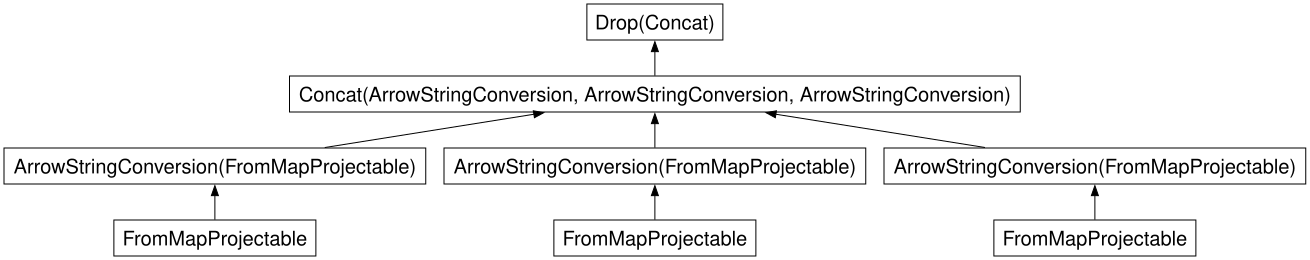

In [10]:
# visulaization

df_final.visualize()

In [11]:
# columns in the final dataset

df_final.columns

Index(['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime',
       'passenger_count', 'trip_distance', 'pickup_longitude',
       'pickup_latitude', 'RatecodeID', 'store_and_fwd_flag',
       'dropoff_longitude', 'dropoff_latitude', 'fare_amount'],
      dtype='object')

In [12]:
# checking few rows

df_final.head(10)

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,pickup_longitude,pickup_latitude,RatecodeID,store_and_fwd_flag,dropoff_longitude,dropoff_latitude,fare_amount
0,2.0,2016-01-01 00:00:00,2016-01-01 00:00:00,2.0,1.10,-73.990372,40.734695,1.0,N,-73.981842,40.732407,7.5
1,2.0,2016-01-01 00:00:00,2016-01-01 00:00:00,5.0,4.90,-73.980782,40.729912,1.0,N,-73.944473,40.716679,18.0
2,2.0,2016-01-01 00:00:00,2016-01-01 00:00:00,1.0,10.54,-73.984550,40.679565,1.0,N,-73.950272,40.788925,33.0
3,2.0,2016-01-01 00:00:00,2016-01-01 00:00:00,1.0,4.75,-73.993469,40.718990,1.0,N,-73.962242,40.657333,16.5
4,2.0,2016-01-01 00:00:00,2016-01-01 00:00:00,3.0,1.76,-73.960625,40.781330,1.0,N,-73.977264,40.758514,8.0
5,2.0,2016-01-01 00:00:00,2016-01-01 00:18:30,2.0,5.52,-73.980118,40.743050,1.0,N,-73.913490,40.763142,19.0
6,2.0,2016-01-01 00:00:00,2016-01-01 00:26:45,2.0,7.45,-73.994057,40.719990,1.0,N,-73.966362,40.789871,26.0
7,1.0,2016-01-01 00:00:01,2016-01-01 00:11:55,1.0,1.20,-73.979424,40.744614,1.0,N,-73.992035,40.753944,9.0
8,1.0,2016-01-01 00:00:02,2016-01-01 00:11:14,1.0,6.00,-73.947151,40.791046,1.0,N,-73.920769,40.865578,18.0
9,2.0,2016-01-01 00:00:02,2016-01-01 00:11:08,1.0,3.21,-73.998344,40.723896,1.0,N,-73.995850,40.688400,11.5


In [20]:
# info

df_final.info

<bound method DataFrame.info of Dask DataFrame Structure:
               VendorID tpep_pickup_datetime tpep_dropoff_datetime passenger_count trip_distance pickup_longitude pickup_latitude RatecodeID store_and_fwd_flag dropoff_longitude dropoff_latitude fare_amount
npartitions=82                                                                                                                                                                                                
                float64               string                string         float64       float64          float64         float64    float64             string           float64          float64     float64
                    ...                  ...                   ...             ...           ...              ...             ...        ...                ...               ...              ...         ...
...                 ...                  ...                   ...             ...           ...              ... 

In [21]:
# dtypes

df_final.dtypes

VendorID                         float64
tpep_pickup_datetime     string[pyarrow]
tpep_dropoff_datetime    string[pyarrow]
passenger_count                  float64
trip_distance                    float64
pickup_longitude                 float64
pickup_latitude                  float64
RatecodeID                       float64
store_and_fwd_flag       string[pyarrow]
dropoff_longitude                float64
dropoff_latitude                 float64
fare_amount                      float64
dtype: object

In [24]:
# checking for the missing value

df_final.isnull().sum().compute()

VendorID                 0
tpep_pickup_datetime     0
tpep_dropoff_datetime    0
passenger_count          0
trip_distance            0
pickup_longitude         0
pickup_latitude          0
RatecodeID               0
store_and_fwd_flag       0
dropoff_longitude        0
dropoff_latitude         0
fare_amount              0
dtype: int64

- there is no missing value in the data

In [ ]:
df_final.compute()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,pickup_longitude,pickup_latitude,RatecodeID,store_and_fwd_flag,dropoff_longitude,dropoff_latitude,fare_amount
0,2.0,2016-01-01 00:00:00,2016-01-01 00:00:00,2.0,1.10,-73.990372,40.734695,1.0,N,-73.981842,40.732407,7.5
1,2.0,2016-01-01 00:00:00,2016-01-01 00:00:00,5.0,4.90,-73.980782,40.729912,1.0,N,-73.944473,40.716679,18.0
2,2.0,2016-01-01 00:00:00,2016-01-01 00:00:00,1.0,10.54,-73.984550,40.679565,1.0,N,-73.950272,40.788925,33.0
3,2.0,2016-01-01 00:00:00,2016-01-01 00:00:00,1.0,4.75,-73.993469,40.718990,1.0,N,-73.962242,40.657333,16.5
4,2.0,2016-01-01 00:00:00,2016-01-01 00:00:00,3.0,1.76,-73.960625,40.781330,1.0,N,-73.977264,40.758514,8.0
...,...,...,...,...,...,...,...,...,...,...,...,...
420272,1.0,2016-03-31 16:34:36,2016-03-31 16:34:36,1.0,0.00,0.000000,0.000000,1.0,Y,0.000000,0.000000,19.0
420273,1.0,2016-03-26 03:02:32,2016-06-14 18:47:55,1.0,0.40,-73.977356,40.774471,1.0,N,-73.982536,40.772408,4.0
420274,1.0,2016-03-20 08:43:59,2016-06-27 15:05:01,1.0,20.20,0.000000,0.000000,2.0,N,-74.008614,40.710987,52.0
420275,1.0,2016-03-20 08:49:47,2016-06-28 19:11:27,1.0,15.40,-73.790077,40.647377,1.0,N,-73.971756,40.578457,42.5


In [29]:
type(df_final)

dask.dataframe.dask_expr._collection.DataFrame

## Analysis

In [31]:
# statistical summary of numerical columns

df_final.describe().compute()

,VendorID,passenger_count,trip_distance,pickup_longitude,pickup_latitude,RatecodeID,dropoff_longitude,dropoff_latitude,fare_amount
count,3.449986e+07,3.449986e+07,3.449986e+07,3.449986e+07,3.449986e+07,3.449986e+07,3.449986e+07,3.449986e+07,3.449986e+07
mean,1.532576e+00,1.661700e+00,5.309408e+00,-7.283942e+01,4.012605e+01,1.039150e+00,-7.290482e+01,4.016297e+01,1.257198e+01
std,4.989377e-01,1.316154e+00,4.672575e+03,9.090656e+00,5.007832e+00,5.564537e-01,8.828348e+00,4.863875e+00,9.179006e+01
min,1.000000e+00,0.000000e+00,-3.390584e+06,-1.616987e+02,-7.703949e+01,1.000000e+00,-1.616987e+02,-7.703949e+01,-9.576000e+02
25%,1.000000e+00,1.000000e+00,1.100000e+00,-7.399055e+01,4.074137e+01,1.000000e+00,-7.399009e+01,4.074001e+01,7.000000e+00
50%,2.000000e+00,1.000000e+00,1.930000e+00,-7.397922e+01,4.075640e+01,1.000000e+00,-7.397832e+01,4.075612e+01,1.000000e+01
75%,2.000000e+00,2.000000e+00,3.800000e+00,-7.396252e+01,4.076979e+01,1.000000e+00,-7.395599e+01,4.077166e+01,1.550000e+01
max,2.000000e+00,9.000000e+00,1.907263e+07,9.464387e+01,6.685682e+01,9.900000e+01,3.889659e+01,4.053167e+02,4.294967e+05


### anamolies

- min. passenger count is 0
- max passenger count is 9

- min trip distance is -ve
- trip distance is highly skewed
- max trip distance is very high

- max pickup_long is +ve
- min pickup lat is -ve

- max rate code id is very high

- max droppoff_long is very high

- min dropoff-lat is -ve

- min fare amount is -ve
- max fare amount is very high

### Vendor ID

In [41]:
df_final['VendorID'].value_counts().compute()

VendorID
2.0    18373797
1.0    16126062
Name: count, dtype: int64

In [42]:
df_final['VendorID'].value_counts(normalize=True).compute()

VendorID
2.0    0.532576
1.0    0.467424
Name: proportion, dtype: float64

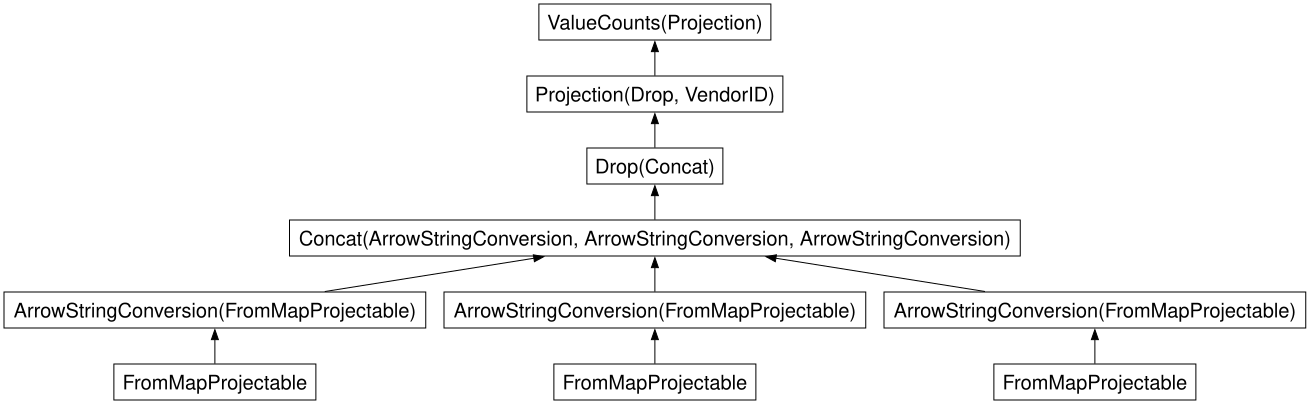

In [51]:
df_final['VendorID'].value_counts().visualize()

In [52]:
vendor_share = df_final['VendorID'].value_counts(normalize=True).compute()

vendor_share

VendorID
2.0    0.532576
1.0    0.467424
Name: proportion, dtype: float64

In [53]:
type(vendor_share)

pandas.core.series.Series

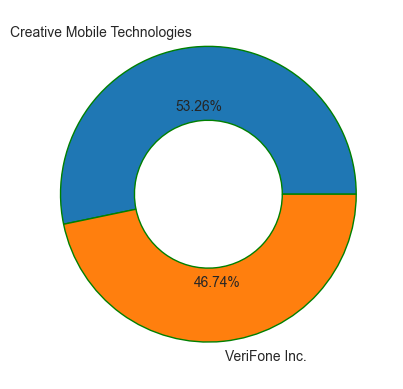

In [66]:
plt.pie(vendor_share,labels=["Creative Mobile Technologies","VeriFone Inc."],autopct='%0.2f%%',radius=1,wedgeprops=dict(width=0.5,edgecolor='green'))
plt.show()

## Passenger Counts

In [69]:
passenger_count = df_final['passenger_count'].value_counts().compute()

passenger_count

passenger_count
8.0          68
0.0        1649
3.0     1383805
4.0      658123
9.0          57
2.0     4904836
6.0     1153190
1.0    24544044
7.0          72
5.0     1854015
Name: count, dtype: int64

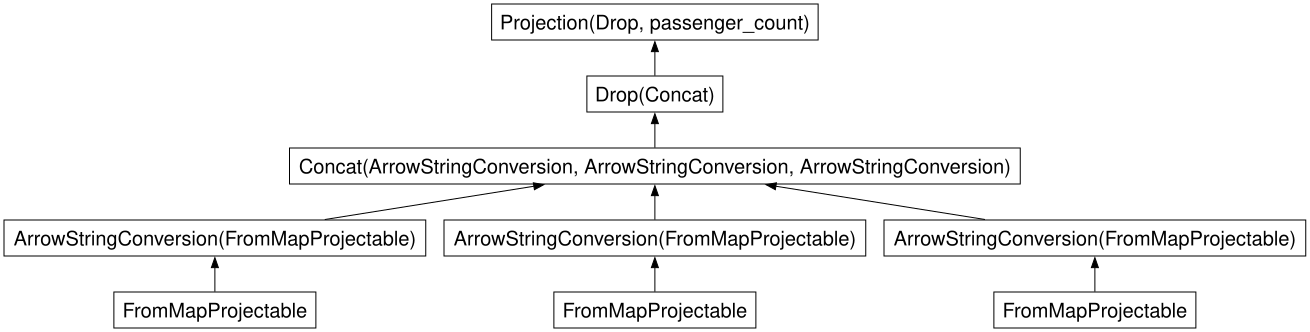

In [72]:
df_final['passenger_count'].visualize()

C:\Users\Jay Kanakia\AppData\Local\Temp\ipykernel_23764\2993017597.py:4: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


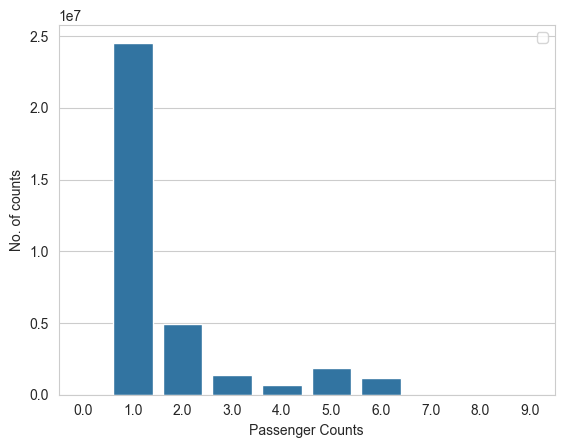

In [74]:
sns.barplot(passenger_count)
plt.xlabel('Passenger Counts')
plt.ylabel('No. of counts')
plt.legend()
plt.show()

- mostly passenger count is in the range if 1 to 6
- 0,7,8,9 needs to be checked

## Trip Distance

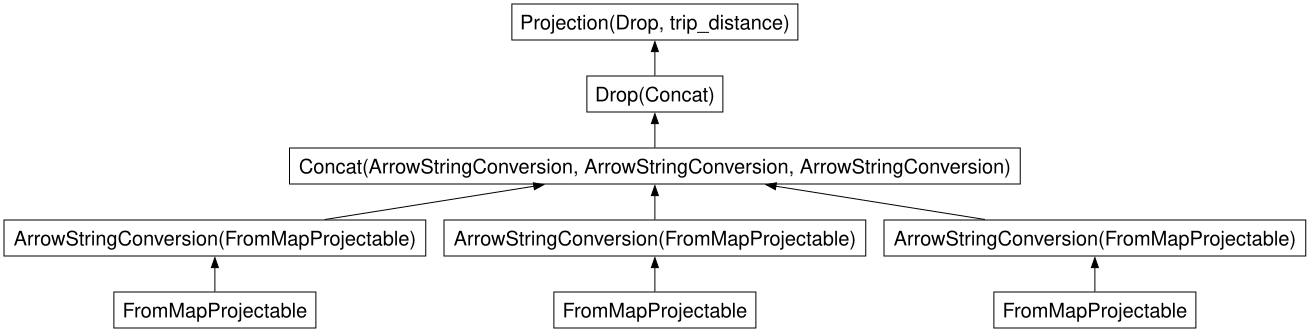

In [75]:
df_final['trip_distance'].visualize()

In [77]:
trip_distance = df_final['trip_distance'].compute()

trip_distance

0          1.10
1          4.90
2         10.54
3          4.75
4          1.76
          ...  
420272     0.00
420273     0.40
420274    20.20
420275    15.40
420276    17.50
Name: trip_distance, Length: 34499859, dtype: float64

<Axes: ylabel='trip_distance'>

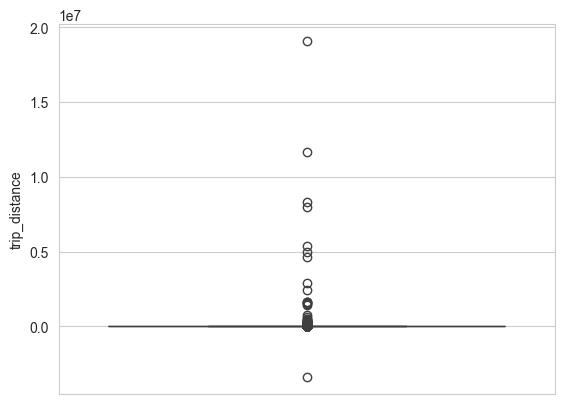

In [ ]:
# box plot for trip distance

sns.boxplot(trip_distance)

In [91]:
for quantile in np.arange(0.1,1.1,0.1):
    print(f'The {int(quantile*100)}th quantile value is {np.quantile(trip_distance,q=quantile)}')

The 10th quantile value is 0.63
The 20th quantile value is 0.9
The 30th quantile value is 1.1
The 40th quantile value is 1.38
The 50th quantile value is 1.69
The 60th quantile value is 2.09
The 70th quantile value is 2.67
The 80th quantile value is 3.7
The 90th quantile value is 6.53
The 100th quantile value is 19072628.8


In [96]:
for quantile in np.arange(0.9,1.01,0.01):
    print(f'The {int(quantile*100)}th quantile value is {np.quantile(trip_distance,q=quantile)}')

The 90th quantile value is 6.53
The 91th quantile value is 7.15
The 92th quantile value is 7.9
The 93th quantile value is 8.7
The 94th quantile value is 9.5
The 95th quantile value is 10.3
The 96th quantile value is 11.4
The 97th quantile value is 13.45
The 98th quantile value is 16.9
The 99th quantile value is 18.56
The 100th quantile value is 19072628.8


- the 100th quantile value is an issue

## Fare Amount

In [97]:
fare_amount = df_final['fare_amount'].compute()

fare_amount

0          7.5
1         18.0
2         33.0
3         16.5
4          8.0
          ... 
420272    19.0
420273     4.0
420274    52.0
420275    42.5
420276    52.0
Name: fare_amount, Length: 34499859, dtype: float64

<Axes: ylabel='fare_amount'>

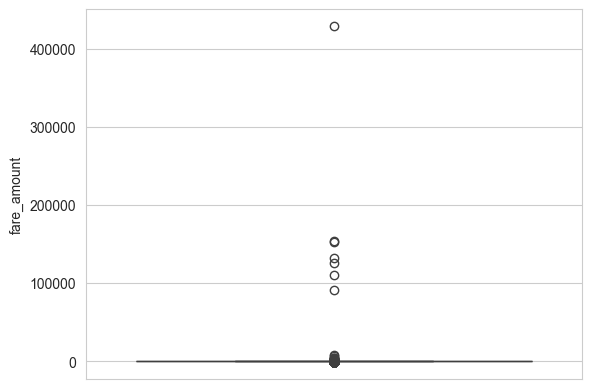

In [98]:
sns.boxplot(fare_amount)

In [99]:
fare_amount.describe()

count    3.449986e+07
mean     1.257198e+01
std      9.179006e+01
min     -9.576000e+02
25%      6.500000e+00
50%      9.000000e+00
75%      1.400000e+01
max      4.294967e+05
Name: fare_amount, dtype: float64

In [105]:
# percentile values

for i in np.arange(0.1,1.1,0.1):
    print(f'The {int(i*100)}th quantile value is {np.quantile(fare_amount,i)}')

The 10th quantile value is 5.0
The 20th quantile value is 6.0
The 30th quantile value is 7.0
The 40th quantile value is 8.0
The 50th quantile value is 9.0
The 60th quantile value is 10.5
The 70th quantile value is 13.0
The 80th quantile value is 16.0
The 90th quantile value is 24.0
The 100th quantile value is 429496.72


In [106]:
# percentile values

for i in np.arange(0.9,1.01,0.01):
    print(f'The {int(i*100)}th quantile value is {np.quantile(fare_amount,i)}')

The 90th quantile value is 24.0
The 91th quantile value is 25.0
The 92th quantile value is 27.0
The 93th quantile value is 29.0
The 94th quantile value is 31.0
The 95th quantile value is 33.5
The 96th quantile value is 37.5
The 97th quantile value is 44.5
The 98th quantile value is 52.0
The 99th quantile value is 52.0
The 100th quantile value is 429496.72


## RateCode Id

In [110]:
rate_code_ids = df_final['RatecodeID'].value_counts().compute()

rate_code_ids

RatecodeID
3.0        56169
4.0        14459
99.0         835
2.0       697595
6.0          320
1.0     33627000
5.0       103481
Name: count, dtype: int64

In [116]:
rate_code_ids.sort_index().index

Index([1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 99.0], dtype='float64', name='RatecodeID')

<Axes: xlabel='RatecodeID', ylabel='count'>

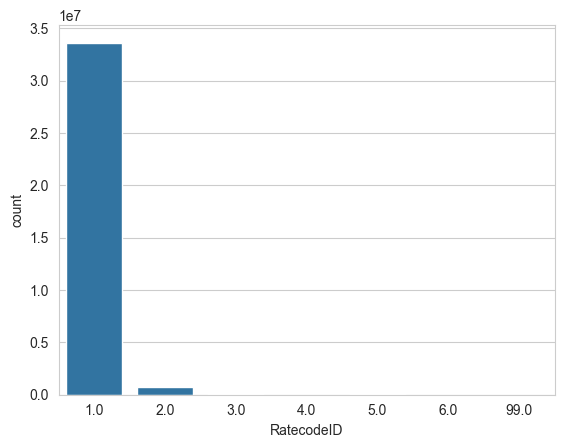

In [117]:
# bar plot

sns.barplot(rate_code_ids)

- 99 seems to be missing value

## Location based columns

In [140]:
# location column subset

location_df = df_final[['pickup_latitude','pickup_longitude', 
                           'dropoff_latitude','dropoff_longitude']].compute()

location_df

,pickup_latitude,pickup_longitude,dropoff_latitude,dropoff_longitude
0,40.734695,-73.990372,40.732407,-73.981842
1,40.729912,-73.980782,40.716679,-73.944473
2,40.679565,-73.984550,40.788925,-73.950272
3,40.718990,-73.993469,40.657333,-73.962242
4,40.781330,-73.960625,40.758514,-73.977264
...,...,...,...,...
420272,0.000000,0.000000,0.000000,0.000000
420273,40.774471,-73.977356,40.772408,-73.982536
420274,0.000000,0.000000,40.710987,-74.008614
420275,40.647377,-73.790077,40.578457,-73.971756


In [143]:
cols = location_df.columns
cols

Index(['pickup_latitude', 'pickup_longitude', 'dropoff_latitude',
       'dropoff_longitude'],
      dtype='object')

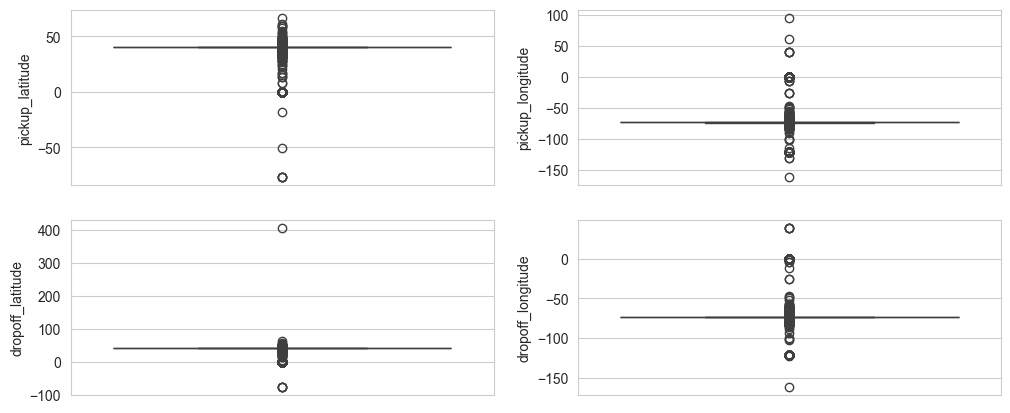

In [147]:
# box plot for location based columns

fig,(ax1,ax2) = plt.subplots(nrows=2,ncols=2,figsize=(12,5))

for i in range(0,4,1):

    if i<=1:
        sns.boxplot(data=location_df,y=cols[i],ax=ax1[i])

    else:
        sns.boxplot(data=location_df,y=cols[i],ax=ax2[2-i])

## Store and Forward flag

In [149]:
store_and_fwd_flag = df_final['store_and_fwd_flag'].compute()

store_and_fwd_flag

0         N
1         N
2         N
3         N
4         N
         ..
420272    Y
420273    N
420274    N
420275    N
420276    N
Name: store_and_fwd_flag, Length: 34499859, dtype: string

<Axes: xlabel='count', ylabel='store_and_fwd_flag'>

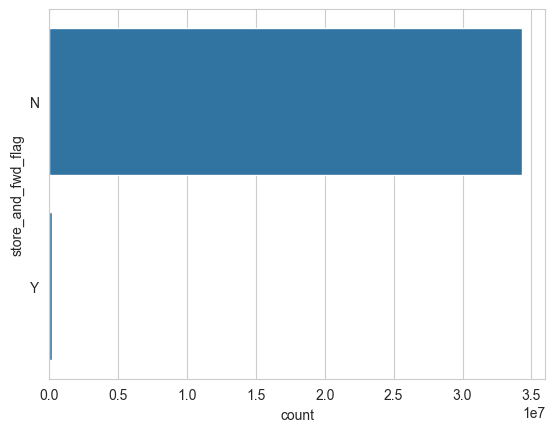

In [150]:
sns.countplot(store_and_fwd_flag)

- most of them forward directly to the vendor without storing

## DateTime columns

In [148]:
df_final.columns

Index(['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime',
       'passenger_count', 'trip_distance', 'pickup_longitude',
       'pickup_latitude', 'RatecodeID', 'store_and_fwd_flag',
       'dropoff_longitude', 'dropoff_latitude', 'fare_amount'],
      dtype='object')

In [152]:
# converting to datetime

df_final['tpep_pickup_datetime'] = dd.to_datetime(df_final['tpep_pickup_datetime'],yearfirst=True,format='mixed')
df_final['tpep_dropoff_datetime'] = dd.to_datetime(df_final['tpep_dropoff_datetime'],yearfirst=True,format='mixed')

In [153]:
# create new columns

df_final['pickup_months'] = df_final['tpep_pickup_datetime'].dt.month
df_final['pickup_day_of_the_week'] = df_final['tpep_pickup_datetime'].dt.dayofweek
df_final['pickup_hour'] = df_final['tpep_pickup_datetime'].dt.hour

In [154]:
df_final

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,pickup_longitude,pickup_latitude,RatecodeID,store_and_fwd_flag,dropoff_longitude,dropoff_latitude,fare_amount,pickup_months,pickup_day_of_the_week,pickup_hour
npartitions=82,,,,,,,,,,,,,,,
,float64,datetime64[ns],datetime64[ns],float64,float64,float64,float64,float64,string,float64,float64,float64,int32,int32,int32
,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...


In [155]:
df_final.columns

Index(['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime',
       'passenger_count', 'trip_distance', 'pickup_longitude',
       'pickup_latitude', 'RatecodeID', 'store_and_fwd_flag',
       'dropoff_longitude', 'dropoff_latitude', 'fare_amount', 'pickup_months',
       'pickup_day_of_the_week', 'pickup_hour'],
      dtype='object')

In [156]:
df_final.dtypes

VendorID                          float64
tpep_pickup_datetime       datetime64[ns]
tpep_dropoff_datetime      datetime64[ns]
passenger_count                   float64
trip_distance                     float64
pickup_longitude                  float64
pickup_latitude                   float64
RatecodeID                        float64
store_and_fwd_flag        string[pyarrow]
dropoff_longitude                 float64
dropoff_latitude                  float64
fare_amount                       float64
pickup_months                       int32
pickup_day_of_the_week              int32
pickup_hour                         int32
dtype: object

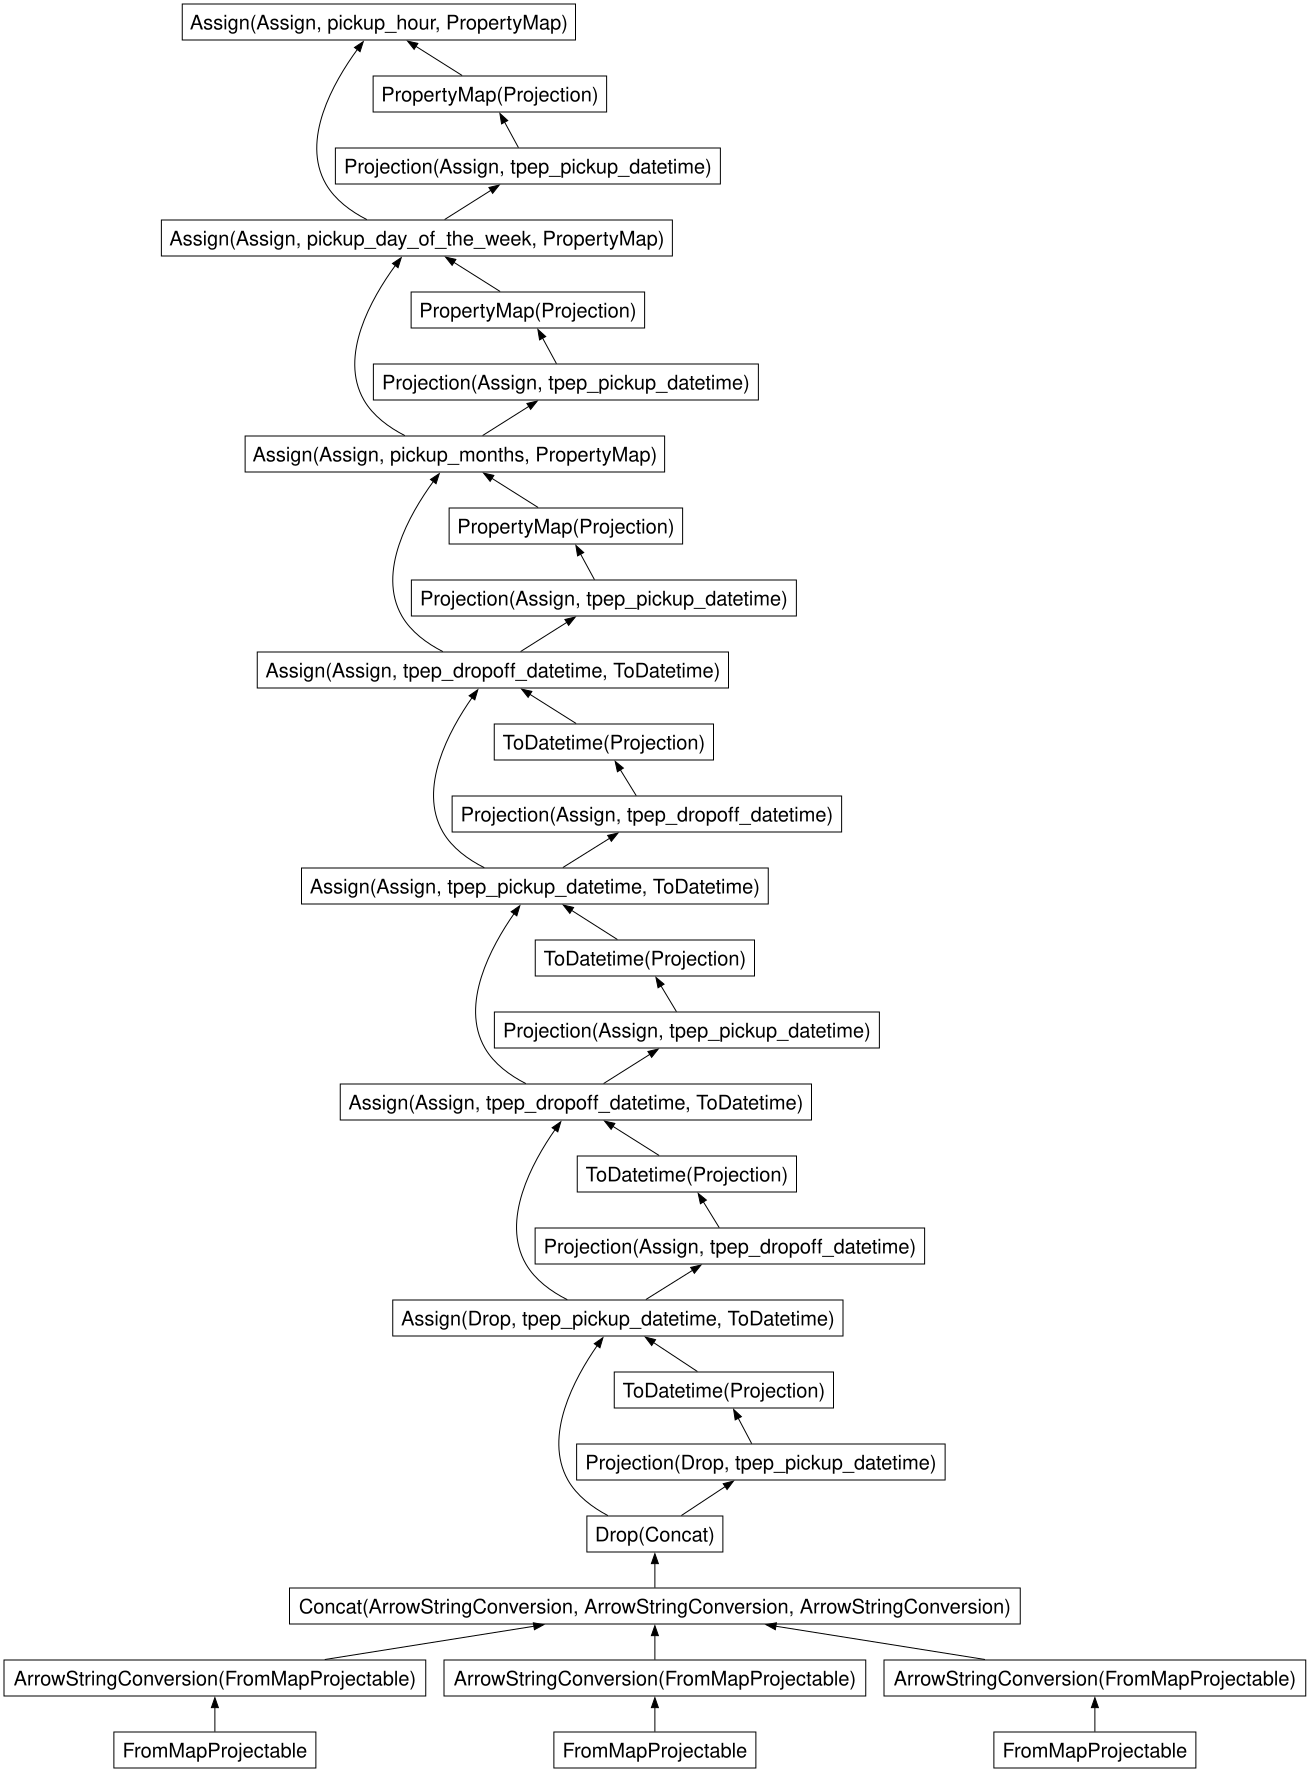

In [157]:
df_final.visualize()

In [164]:
# pickup every 3 days

pickup_every_3_days = df_final.set_index('tpep_pickup_datetime').resample('3D').size().compute()

pickup_every_3_days

tpep_pickup_datetime
2016-01-01     960746
2016-01-04    1007938
2016-01-07    1162789
2016-01-10    1061829
2016-01-13    1192852
2016-01-16    1132536
2016-01-19    1166946
2016-01-22     658061
2016-01-25     968922
2016-01-28    1232734
2016-01-31    1065990
2016-02-03    1176173
2016-02-06    1144752
2016-02-09    1192598
2016-02-12    1285409
2016-02-15    1101217
2016-02-18    1256220
2016-02-21    1114674
2016-02-24    1251497
2016-02-27    1155024
2016-03-01    1208179
2016-03-04    1270530
2016-03-07    1106194
2016-03-10    1273983
2016-03-13    1134075
2016-03-16    1234570
2016-03-19    1176151
2016-03-22    1155525
2016-03-25    1149227
2016-03-28    1108463
2016-03-31     394055
Freq: 3D, dtype: int64

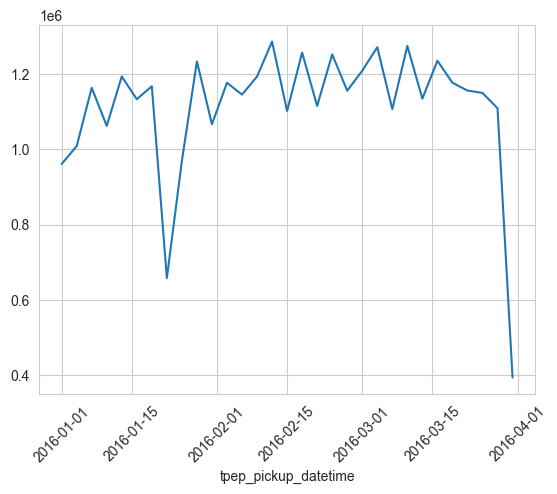

In [166]:
# line plot

sns.lineplot(pickup_every_3_days)
plt.xticks(rotation=45)
plt.show()

In [172]:
# pickup each hour of the day

pickup_each_hour = df_final.groupby(['pickup_hour','pickup_day_of_the_week'])['VendorID'].count().compute()

pickup_each_hour

pickup_hour  pickup_day_of_the_week
4            2                          29498
             3                          32480
5            2                          49844
6            2                         136330
             3                         138392
                                        ...  
23           5                         299024
0            0                         100903
             1                         101299
19           0                         291911
23           0                         154325
Name: VendorID, Length: 168, dtype: int64

In [173]:
pickup_each_hour = pickup_each_hour.reset_index()

pickup_each_hour

,pickup_hour,pickup_day_of_the_week,VendorID
0,4,2,29498
1,4,3,32480
2,5,2,49844
3,6,2,136330
4,6,3,138392
...,...,...,...
163,23,5,299024
164,0,0,100903
165,0,1,101299
166,19,0,291911


In [177]:
pickup_each_hour.rename(columns = {'VendorID':'Number of Pickups'},inplace=True)

pickup_each_hour

,pickup_hour,pickup_day_of_the_week,Number of Pickups
0,4,2,29498
1,4,3,32480
2,5,2,49844
3,6,2,136330
4,6,3,138392
...,...,...,...
163,23,5,299024
164,0,0,100903
165,0,1,101299
166,19,0,291911


In [178]:
day_name = ['Mon','Tue','Wed','Thur','Fri','Sat','Sun']

replacement_mapper = {k:v for k,v in enumerate(day_name)}

replacement_mapper

{0: 'Mon', 1: 'Tue', 2: 'Wed', 3: 'Thur', 4: 'Fri', 5: 'Sat', 6: 'Sun'}

In [181]:
pickup_each_hour.replace({'pickup_day_of_the_week':replacement_mapper},inplace=True)

In [182]:
pickup_each_hour

,pickup_hour,pickup_day_of_the_week,Number of Pickups
0,4,Wed,29498
1,4,Thur,32480
2,5,Wed,49844
3,6,Wed,136330
4,6,Thur,138392
...,...,...,...
163,23,Sat,299024
164,0,Mon,100903
165,0,Tue,101299
166,19,Mon,291911


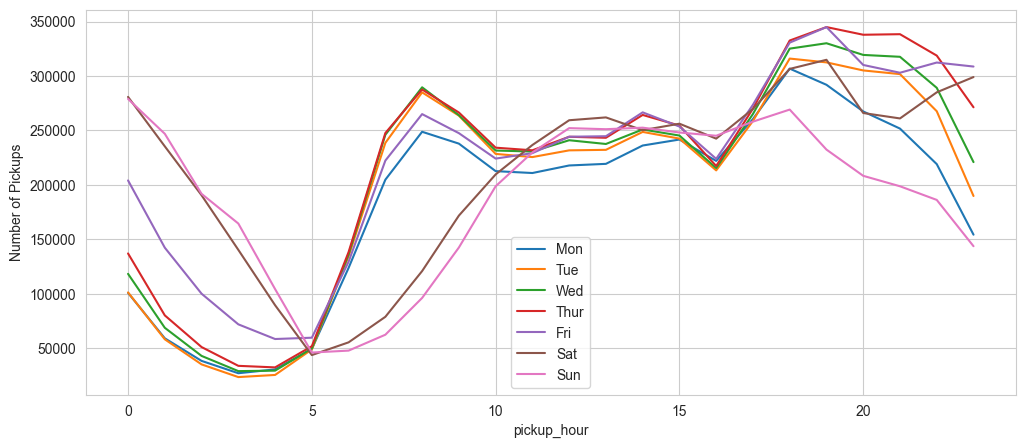

In [196]:
# plot the line plot

plt.figure(figsize=(12,5))
sns.lineplot(pickup_each_hour,x='pickup_hour',y='Number of Pickups',hue='pickup_day_of_the_week',hue_order=day_name)
plt.legend(loc=8)
plt.show()

- Weekend graphs are smoother as compared to weekdays graph